<a href="https://colab.research.google.com/github/ks-orintis/machine-learning/blob/main/%D0%9B%D0%A02_1_%D0%9B%D1%83%D1%87%D0%B0%D0%BD%D1%96%D0%BD%D0%BE%D0%B2%D0%B0_%D0%9A%D1%81%D0%B5%D0%BD%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2.1

---



In [1]:
import numpy as np
import pandas as pd
import requests

# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_8176/3544548059.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [3]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


In [6]:
df.dtypes

,0
Country/Territory,object
IMF (2026)[1],object
World Bank (2025)[6],object
United Nations (2024)[7],object


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [7]:
df.columns = (df.columns
              .str.replace(r'\[\d+\]', '', regex=True)
              .str.replace(r'[()]', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False)
              .str.strip()
              )
df

,Country,IMF 2026,World Bank 2025,United Nations 2024
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [8]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF 2026,World Bank 2025,United Nations 2024
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [9]:
df.isnull().sum()

,0
Country,0
IMF 2026,0
World Bank 2025,0
United Nations 2024,0


In [10]:
df['IMF 2026'] = pd.to_numeric(df['IMF 2026'], errors='coerce')
df['World Bank 2025'] = pd.to_numeric(df['World Bank 2025'], errors='coerce')
df['United Nations 2024'] = pd.to_numeric(df['United Nations 2024'], errors='coerce')

In [11]:
df.dtypes

,0
Country,object
IMF 2026,float64
World Bank 2025,float64
United Nations 2024,float64


In [12]:
df

,Country,IMF 2026,World Bank 2025,United Nations 2024
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [13]:
df.isnull().sum()

,0
Country,0
IMF 2026,31
World Bank 2025,35
United Nations 2024,9


In [15]:
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(df.iloc[:, 1:].mean())

df.isnull().sum()

,0
Country,0
IMF 2026,0
World Bank 2025,0
United Nations 2024,0


5. Ще раз вивести датасет

In [16]:
df.tail(10)

,Country,IMF 2026,World Bank 2025,United Nations 2024
212,Saint Martin,594338.521127,556140.901408,524623.732394
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,456.000000,456.000000,456.000000
215,Cook Islands,414.000000,414.000000,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,81.000000,81.000000,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [17]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [18]:
df.describe()

,IMF 2026,World Bank 2025,United Nations 2024
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [19]:
df['IMF_WB_Diff'] = abs(df['IMF 2026'] - df['World Bank 2025'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]

print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF 2026,World Bank 2025,United Nations 2024,IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [20]:
Cor_IMF_WB = df['IMF 2026'].corr(df['World Bank 2025'])
Cor_IMF_UN = df['IMF 2026'].corr(df['United Nations 2024'])
Cor_WB_UN = df['World Bank 2025'].corr(df['United Nations 2024'])

print(f'Correlation between IMF and WB: {Cor_IMF_WB}')
print(f'Correlation between IMF and UN: {Cor_IMF_UN}')
print(f'Correlation between WB and UN: {Cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between WB and UN: 0.9998603541665632


In [21]:
max_cor = max(Cor_IMF_WB, Cor_IMF_UN, Cor_WB_UN)

if max_cor == Cor_IMF_WB:
  print('IMF and WB have the highest correlation')
elif max_cor == Cor_IMF_UN:
  print('IMF and UN have the highest correlation')
else:
  print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [22]:
mean_IMF = df['IMF 2026'].mean()
mean_IMF

np.float64(594338.5211267605)

In [23]:
mean_WB = df['World Bank 2025'].mean()
mean_WB

np.float64(556140.9014084507)

In [24]:
mean_UN = df['United Nations 2024'].mean()
mean_UN

np.float64(524623.7323943662)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [25]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()

country = df[df['std'] == max_std]['Country'].values[0]

print(f'{country} has the highest standart deviation: {max_std}')

df.head(10)

United States has the highest standart deviation: 14655779.964896671


,Country,IMF 2026,World Bank 2025,United Nations 2024,IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [26]:
max_IMF = df['IMF 2026'].max(); min_IMF = df['IMF 2026'].min()
max_WB = df['World Bank 2025'].max(); min_WB = df['World Bank 2025'].min()
max_UN = df['United Nations 2024'].max(); min_UN = df['United Nations 2024'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

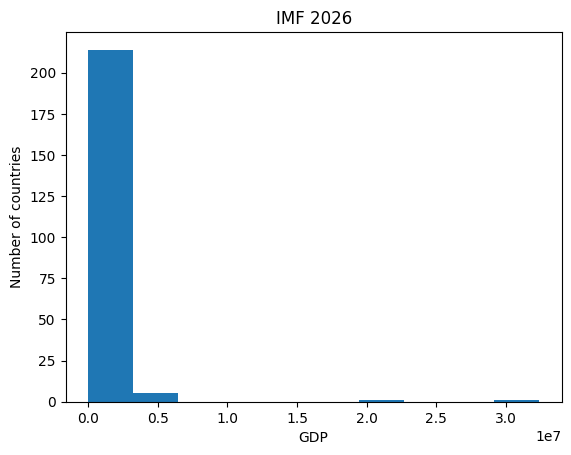

In [29]:
import matplotlib.pyplot as plt

plt.hist(df['IMF 2026'], bins=10)
plt.title('IMF 2026')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

Більшість країн мають невеликі показники IMF 2026, а США та Китай явно виділяються високими значеннями.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [38]:
df['IMF_Share'] = df['IMF 2026'] / df['IMF 2026'].sum() * 100
df['WB_Share'] = df['World Bank 2025'] / df['World Bank 2025'].sum() * 100
df['UN_Share'] = df['United Nations 2024'] / df['United Nations 2024'].sum() * 100

df[['Country', 'UN_Share', 'WB_Share', 'IMF_Share']].head(10).round(2)

,Country,UN_Share,WB_Share,IMF_Share
1,United States,25.27,25.03,24.65
2,China[n 1],16.17,15.86,15.87
3,Germany,4.02,4.11,4.15
4,Japan,3.47,3.61,3.33
5,United Kingdom,3.18,3.26,3.25
6,India,3.41,3.22,3.16
7,France,2.73,2.74,2.74
8,Italy,2.05,2.08,2.08
9,Russia,1.87,2.08,2.02
10,Brazil,1.89,1.85,2.01


Частки більшості країн змінюються незначно. У США та Індії спостерігається поступове зменшення частки, у Німеччині та Італії - зростання, а в Японії та Росії показники коливаються.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

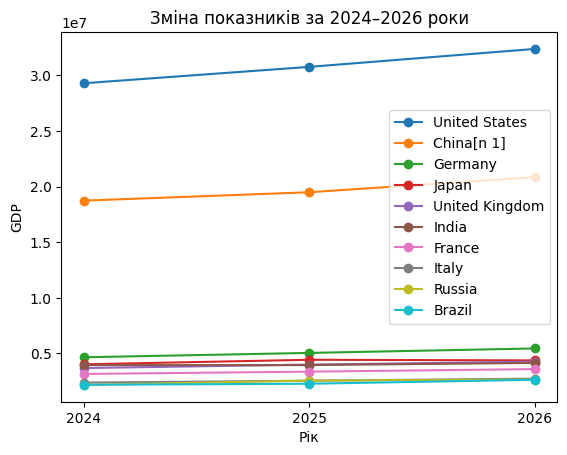

In [34]:
data = df[df['Country'] != 'World'].head(10)

for _, row in data.iterrows():
    plt.plot(
        [2024, 2025, 2026],
        [row['United Nations 2024'],
         row['World Bank 2025'],
         row['IMF 2026']],
        marker='o',
        label=row['Country']
    )

plt.xticks([2024, 2025, 2026])

plt.xlabel('Рік')
plt.ylabel('GDP')
plt.title('Зміна показників за 2024–2026 роки')
plt.legend()
plt.show()

In [39]:
growth = df[
    (df['United Nations 2024'] < df['World Bank 2025']) &
    (df['World Bank 2025'] < df['IMF 2026'])
]

decline = df[
    (df['United Nations 2024'] > df['World Bank 2025']) &
    (df['World Bank 2025'] > df['IMF 2026'])
]

print("Стабільне зростання:")
for country in growth['Country']:
    print("-", country)

print("\nСтабільний спад:")
for country in decline['Country']:
    print("-", country)

Стабільне зростання:
- United States
- China[n 1]
- Germany
- United Kingdom
- India
- France
- Italy
- Russia
- Brazil
- Canada
- Spain
- Turkey
- Indonesia
- Netherlands
- Saudi Arabia
- Switzerland
- Poland
- Ireland
- Belgium
- Sweden
- Israel
- Argentina
- Singapore
- Austria
- United Arab Emirates
- Norway
- Thailand
- Colombia
- Vietnam
- Malaysia
- Philippines
- Bangladesh
- Denmark
- Romania
- South Africa
- Hong Kong[n 4]
- Czech Republic
- Egypt
- Chile
- Peru
- Portugal
- Nigeria
- Kazakhstan
- Finland
- Algeria
- Greece
- New Zealand
- Hungary
- Ukraine[n 5]
- Morocco
- Uzbekistan
- Slovakia
- Angola
- Bulgaria
- Kenya
- Ecuador
- Dominican Republic
- Guatemala
- DR Congo
- Ghana
- Oman
- Croatia
- Ivory Coast
- Serbia
- Luxembourg
- Costa Rica
- Lithuania
- Belarus
- Uruguay
- Panama
- Tanzania[n 6]
- Slovenia
- Myanmar
- Bolivia
- Azerbaijan
- Uganda
- Cameroon
- Jordan
- Tunisia
- Paraguay
- Zimbabwe
- Macau[n 7]
- Latvia
- Cambodia
- Estonia
- Nepal
- Cyprus[n 8]
- Ice